# Plot Data per Grain with Scatter
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0
* Prerequisites (Python): seaborn
* Prerequisites (data): DADF5 results file with 1. Piola-Kirchhoff stress ('P') and deformation gradient ('F')

In [1]:
%matplotlib inline

In [2]:
import damask
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# adjust to your situation
result_file = 'plot_per_grain_scatter/20grains16x16x16_tensionX_material.hdf5'

grains = [1,4,19] # corresponds to the material ID in the vti file/material.yaml

In [4]:
result = damask.Result(result_file)

In [5]:
result.export_simulation_setup()
grid_file = '20grains16x16x16.vti'
grid   = damask.GeomGrid.load(grid_file)

In [6]:
# loop over all increments and store P(1,1) per grain and avg(F(1,1))
data = {g:pd.DataFrame() for g in grains}
for inc in result.get(['F','P']).values():
    P = inc['P']
    F = inc['F']
    for g in grains:
        points = grid.material.flatten(order='F')==g
        P_11 = P[points,0,0].flatten()
        F_11 = np.broadcast_to(np.average(F[:,0,0]),P_11.shape)
        x = pd.DataFrame({'F_11':F_11,'P_11':P_11})
        data[g] = pd.concat((data[g],x),ignore_index=True)

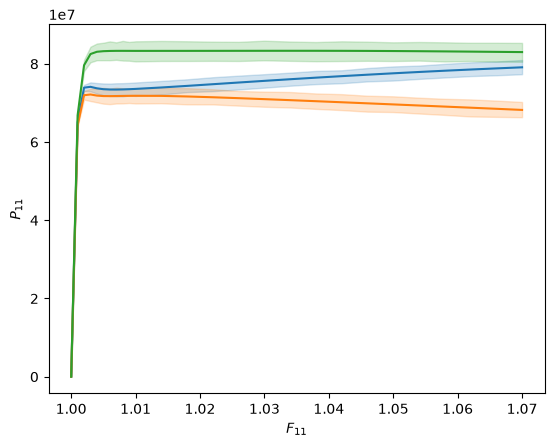

In [7]:
for g in grains:
   plot = sns.lineplot(y='P_11',x='F_11',data=data[g])

plot.set(ylabel='$P_{11}$', xlabel=r'$F_{11}$')
fig = plot.get_figure()